<a href="https://colab.research.google.com/github/DillliBabu/Advance_Data_Analysis_Project/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np




In [11]:
df=pd.read_csv('/content/drive/MyDrive/vgsales.csv')

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


'How many rows and columns are in the dataset?\n\nWhich columns are categorical and which are numerical?\n\nFind:\n\ntop 5 genres by count\n\ntop 5 publishers by total sales\n\nWhat is the average global sales per game?\n\nWhich year has the maximum number of games released?'

In [12]:
# How many rows and columns are in the dataset?
df.shape

(16598, 11)

In [13]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [15]:
# Which columns are categorical and which are numerical?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [16]:
# top 5 genres by count
df['Genre'].value_counts().head(5)

,count
Genre,
Action,3316
Sports,2346
Misc,1739
Role-Playing,1488
Shooter,1310


In [20]:
# top 5 publishers by total sales
df.groupby('Publisher')[[
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
  ]].sum().sort_values(by='Global_Sales',ascending=False).head(5)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Publisher,,,,,
Nintendo,816.87,418.74,455.42,95.33,1786.56
Electronic Arts,595.07,371.27,14.04,129.77,1110.32
Activision,429.70,215.53,6.54,75.34,727.46
Sony Computer Entertainment,265.22,187.72,74.10,80.45,607.50
Ubisoft,253.43,163.32,7.50,50.26,474.72


In [31]:
## What is the average global sales per game?
df.groupby('Name')["Global_Sales"].mean().sort_values(ascending=False).head(10)


,Global_Sales
Name,
Wii Sports,82.74
Mario Kart Wii,35.82
Wii Sports Resort,33.00
Pokemon Red/Pokemon Blue,31.37
New Super Mario Bros.,30.01
Wii Play,29.02
New Super Mario Bros. Wii,28.62
Duck Hunt,28.31
Nintendogs,24.76


In [27]:
## Which year has the maximum number of games released?
df['Year'].sort_values(ascending=False).head(1)

,Year
5957,2020.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# **Univariate Visualization**

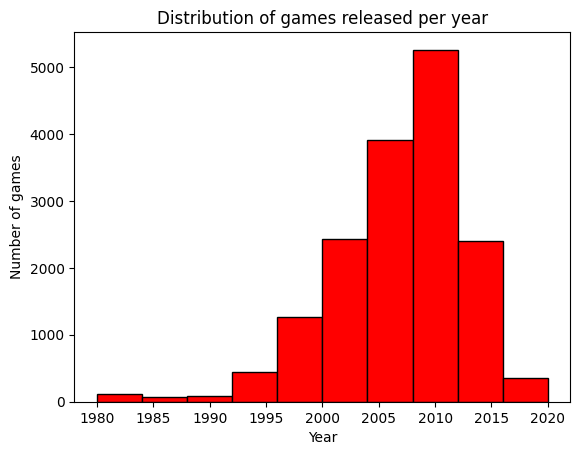

In [17]:
## Distribution of games released per year
## → (Histogram)
# made by matplotlib
plt.hist(df['Year'],color='Red', edgecolor='Black')
plt.title('Distribution of games released per year')
plt.xlabel('Year')
plt.ylabel('Number of games')
plt.show()




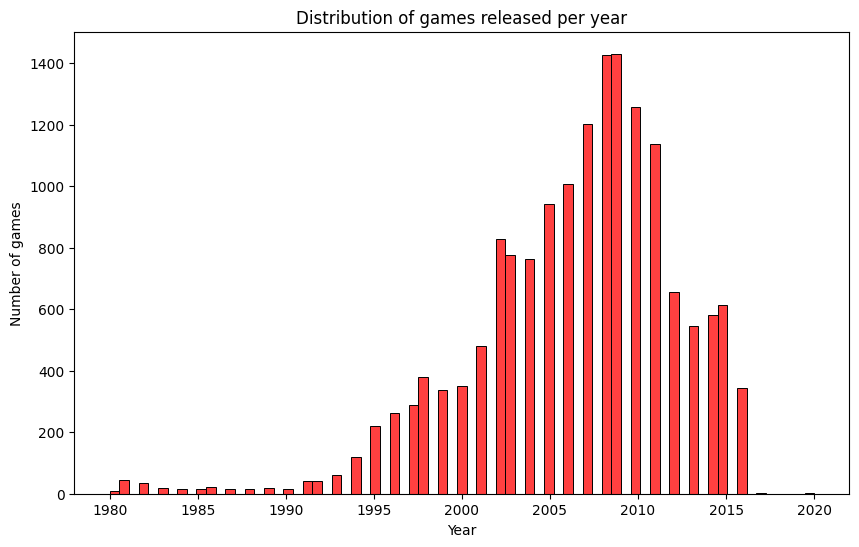

In [27]:
# ## Distribution of games released per year
## → (Histogram)
# made by seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['Year'],color='Red', edgecolor='Black')
plt.title('Distribution of games released per year')
plt.xlabel('Year')
plt.ylabel('Number of games')
plt.show()

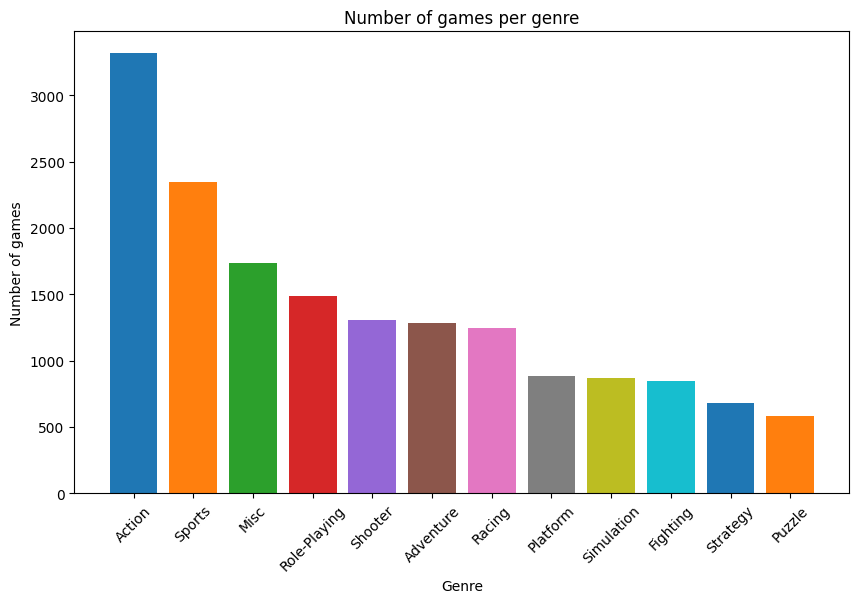

In [34]:
## Count of games per genre
## → (Bar chart / Countplot)
# made by matplotlib
plt.figure(figsize=(10, 6))
generes = df['Genre'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467d6', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.bar(generes.index, generes.values, color=colors)
plt.xticks(rotation=45)
plt.title('Number of games per genre')
plt.xlabel('Genre')
plt.ylabel('Number of games')
plt.show()

/tmp/ipython-input-292507671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genre', data=df, palette='Set2')


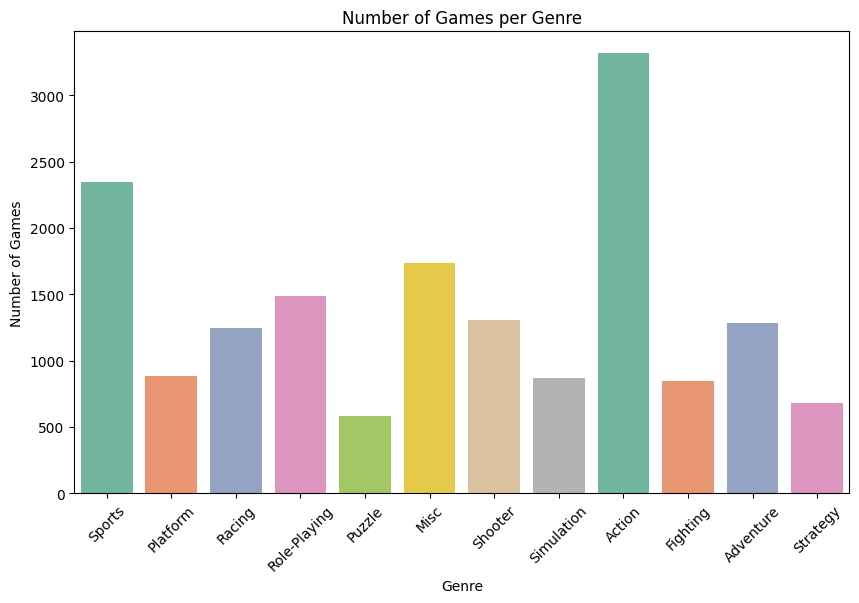

In [29]:
## Count of games per genre
## → (Bar chart / Countplot)
# made by seaborn
plt.figure(figsize=(10, 6))
# Countplot automatically counts the genres
sns.countplot(x='Genre', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Number of Games per Genre')
plt.show()


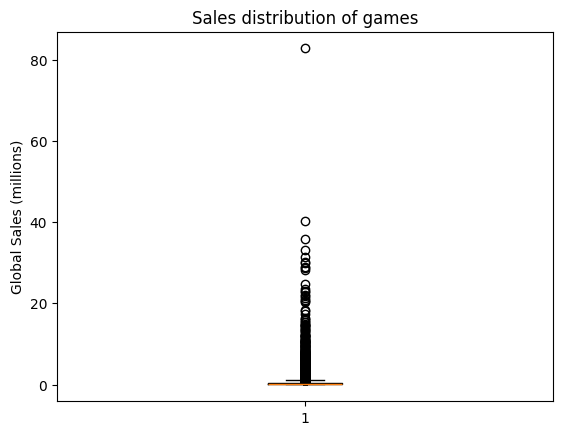

In [20]:
## Sales distribution of games
## → (Boxplot)
plt.boxplot(df['Global_Sales'])
plt.title('Sales distribution of games')
plt.ylabel('Global Sales (millions)')
plt.show()

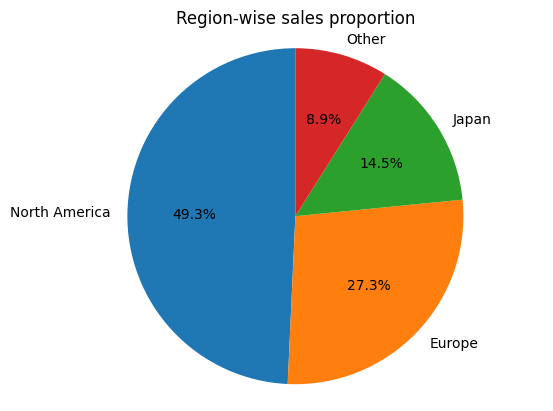

In [25]:
## Region-wise sales proportion
## → (Pie chart)

# Sum of all region
NA_Sales = df['NA_Sales'].sum()
EU_Sales = df['EU_Sales'].sum()
JP_Sales = df['JP_Sales'].sum()
Other_Sales = df['Other_Sales'].sum()

# Data's tranform into list because pie expect data's into list
sales = [NA_Sales, EU_Sales, JP_Sales, Other_Sales]
regions = ['North America', 'Europe', 'Japan', 'Other']

# chart
plt.pie(sales, labels=regions, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Region-wise sales proportion')
plt.show()

In [22]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [35]:
# we can't use pie in seaborn so, move on next

In [36]:
# Bivariate Analysis

# **Bivariate** **Analysis**